# 🧬 Variational Autoencoders (VAE)

In the previous notebook, we saw that standard **Autoencoders (AEs)** are excellent for reconstruction and feature learning. However, they fail as **Generative Models**.

### The Problem with Standard AEs
If you randomly sample a point $\mathbf{z}$ from the AE's latent space, the resulting image generated by the decoder ($\mathbf{x'} = \text{Decoder}(\mathbf{z})$) is usually blurry or incoherent noise. Why?

The AE's latent space is **unstructured**. It only learns to map the training examples to dense pockets, leaving vast, empty, or meaningless regions between them.

### The VAE Solution: Probabilistic Encoding
A **Variational Autoencoder (VAE)** imposes a strict **regularization** constraint on the latent space, forcing the latent codes $\mathbf{z}$ to follow a well-behaved probability distribution, typically a **standard Gaussian $\mathcal{N}(0, 1)$**.

**The Key Change:** Instead of the Encoder outputting a single point $\mathbf{z}$, it outputs the parameters ($\mu$ and $\sigma^2$) of a probability distribution $q(\mathbf{z}|\mathbf{x})$.

## 1. Architecture and The Reparameterization Trick

The VAE architecture looks similar to the AE, but the mechanism inside the Encoder is fundamentally different.

![variational autoencoder architecture](https://media.geeksforgeeks.org/wp-content/uploads/20231201153426/Variational-AutoEncoder.png)

### 1. Probabilistic Encoder
The Encoder (often called the **Inference Network**) outputs two vectors for every input $\mathbf{x}$:
* **Mean vector ($\mu$):** The center of the Gaussian distribution.
* **Log Variance vector ($\log \sigma^2$):** We use log variance because variance must be positive, and logarithms help with numerical stability.

### 2. The Reparameterization Trick
Since the operation of **sampling** from a distribution is non-deterministic, we cannot backpropagate gradients through it directly. The **Reparameterization Trick** solves this:

Instead of sampling $\mathbf{z} \sim q(\mathbf{z}|\mathbf{x})$, we express $\mathbf{z}$ as a deterministic function of a simple, noise variable $\epsilon$:

$$\mathbf{z} = \mu + \sigma \odot \epsilon$$

Where:
* $\epsilon \sim \mathcal{N}(0, 1)$ (Standard Gaussian Noise).
* $\sigma = \exp(0.5 \cdot \log \sigma^2)$ (Standard deviation).

This way, the randomness is factored out into $\epsilon$, and the parameters $\mu$ and $\sigma$ remain differentiable, allowing gradients to flow back into the Encoder.

## 2. The VAE Loss Function (ELBO)

The total VAE loss is the **Evidence Lower Bound (ELBO)**, which is composed of two competing terms:

$$\mathcal{L}_{VAE} = \underbrace{\mathcal{L}_{Reconstruction}}_{\text{Minimize}} + \underbrace{\beta \cdot \mathcal{L}_{KL}}_{\text{Minimize}}$$

### 1. Reconstruction Loss ($\mathcal{L}_{Reconstruction}$)
This term ensures the decoder can accurately reconstruct the input, just like in a standard AE. We will use **Binary Cross-Entropy (BCE)**, which is suitable for binary/normalized image pixel data.

### 2. KL Divergence Loss ($\mathcal{L}_{KL}$)
This is the **regularization** term. It measures the difference between the learned latent distribution $q(\mathbf{z}|\mathbf{x})$ (defined by $\mu$ and $\sigma^2$) and the simple prior distribution $p(\mathbf{z})$ ($\mathcal{N}(0, 1)$).

Minimizing this term forces the network to organize the latent space, ensuring that similar images cluster together and that the entire space is smoothly distributed, making random sampling meaningful.

For a diagonal Gaussian, the KL loss formula is:
$$\mathcal{L}_{KL} = -0.5 \sum_{i=1}^{D} (1 + \log(\sigma_{i}^2) - \mu_{i}^2 - \sigma_{i}^2)$$

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- 1. Define the VAE Architecture ---

class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # --- Encoder (Outputs parameters for the latent distribution) ---
        self.encoder_conv = nn.Sequential(
            # Input: 1 x 28 x 28
            nn.Conv2d(1, 16, kernel_size=3, padding=1), # 16 x 28 x 28
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),                  # 16 x 14 x 14
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # 32 x 14 x 14
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),                  # 32 x 7 x 7
            nn.Flatten()
        )

        # Linear layers to output Mu and Log_Var
        self.fc_mu = nn.Linear(32 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(32 * 7 * 7, latent_dim)

        # --- Decoder setup ---
        self.fc_decode = nn.Linear(latent_dim, 32 * 7 * 7)

        self.decoder = nn.Sequential(
            # Unflattened input: 32 x 7 x 7
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # 16 x 14 x 14
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 1 x 28 x 28
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        """The Reparameterization Trick"""
        # Calculate standard deviation: sigma = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)

        # Sample epsilon ~ N(0, 1)
        eps = torch.randn_like(std)

        # z = mu + sigma * epsilon
        return mu + eps * std

    def forward(self, x):
        batch_size = x.size(0)

        # 1. Encode
        h = self.encoder_conv(x)

        # 2. Get Mu and Log_Var
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        # 3. Sample Latent Vector z
        z = self.reparameterize(mu, logvar)

        # 4. Decoder Prep (Expand)
        x = self.fc_decode(z)
        x = x.view(batch_size, 32, 7, 7) # Reshape back to feature map

        # 5. Decode
        x_prime = self.decoder(x)
        return x_prime, mu, logvar

Using device: cuda


## 3. The Custom VAE Loss Function

We define a custom loss function that combines the **BCE Reconstruction Loss** and the **KL Divergence Regularization Loss**.

In [2]:
def vae_loss_function(recon_x, x, mu, logvar):
    """
    Computes the Evidence Lower Bound (ELBO) loss.
    """
    # 1. Reconstruction Loss (Binary Cross-Entropy)
    # The output is 1x28x28, we flatten it for BCE
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # 2. KL Divergence Loss (Regularization)
    # KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KL_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total VAE Loss
    return BCE + KL_divergence


# --- 4. Data Loading and Training Setup ---

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# --- 5. Training Setup ---
LATENT_DIM = 20 # A common choice for MNIST
model = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

N_EPOCHS = 15
print(f"Starting VAE training for {N_EPOCHS} epochs...")

# --- 6. Training Loop ---
for epoch in range(N_EPOCHS):
    model.train()
    train_loss = 0

    for data in train_loader:
        img, _ = data
        img = img.to(device)

        optimizer.zero_grad()

        recon_batch, mu, logvar = model(img)
        loss = vae_loss_function(recon_batch, img, mu, logvar)

        loss.backward()
        optimizer.step()

        # Normalize the loss by the batch size for reporting
        train_loss += loss.item() / len(img)

    avg_train_loss = train_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{N_EPOCHS}, Train ELBO Loss: {avg_train_loss:.2f}')

print("VAE Training complete.")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.47MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 123kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


Starting VAE training for 15 epochs...
Epoch 1/15, Train ELBO Loss: 182.99
Epoch 2/15, Train ELBO Loss: 125.87
Epoch 3/15, Train ELBO Loss: 119.95
Epoch 4/15, Train ELBO Loss: 115.91
Epoch 5/15, Train ELBO Loss: 113.28
Epoch 6/15, Train ELBO Loss: 111.59
Epoch 7/15, Train ELBO Loss: 110.27
Epoch 8/15, Train ELBO Loss: 109.26
Epoch 9/15, Train ELBO Loss: 108.56
Epoch 10/15, Train ELBO Loss: 108.02
Epoch 11/15, Train ELBO Loss: 107.55
Epoch 12/15, Train ELBO Loss: 107.19
Epoch 13/15, Train ELBO Loss: 106.86
Epoch 14/15, Train ELBO Loss: 106.60
Epoch 15/15, Train ELBO Loss: 106.36
VAE Training complete.


## 4. Evaluation and Visualization: Generative Capability

The VAE's main power is generation. Because the KL divergence term forces the latent space $\mathbf{z}$ to be structured like a **Standard Gaussian $\mathcal{N}(0, 1)$**, we can now sample a random $\mathbf{z}$ from $\mathcal{N}(0, 1)$ and feed it to the decoder to produce a meaningful, novel image.

If we did this with a standard AE, we would get noise.

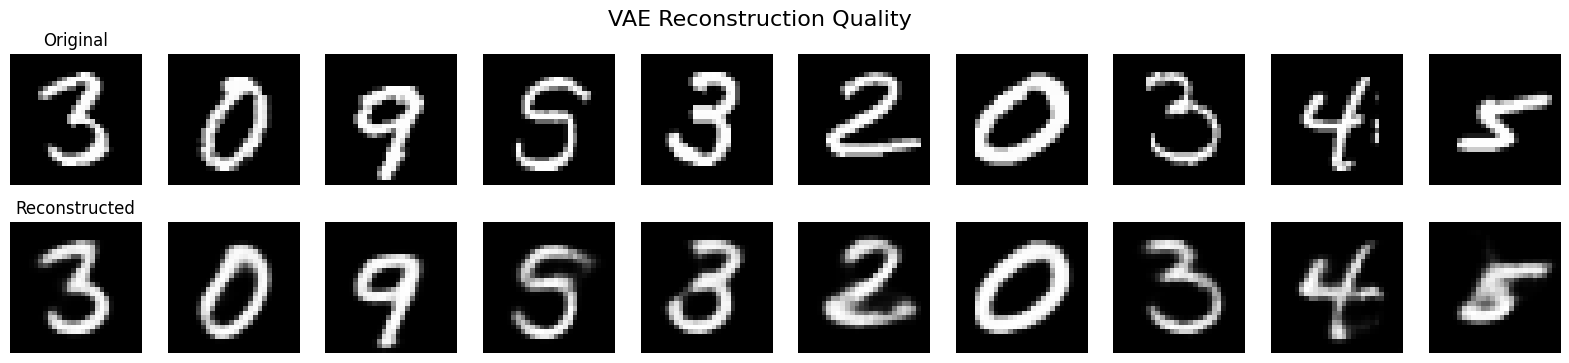

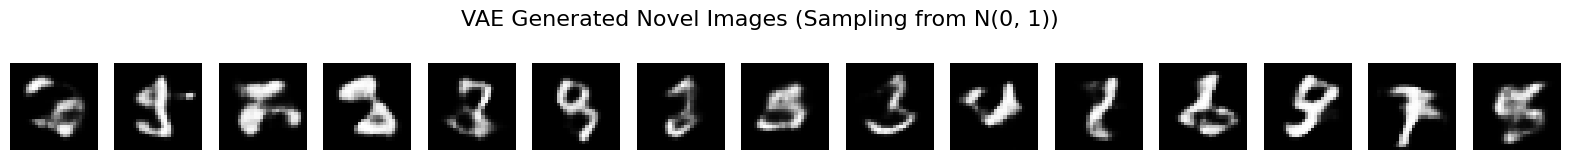

In [3]:
# --- 1. Reconstruction Test (Briefly) ---
model.eval()
test_loader_iter = iter(DataLoader(datasets.MNIST('./data', train=False, transform=transform), batch_size=10, shuffle=True))
images_original, _ = next(test_loader_iter)

with torch.no_grad():
    images_original = images_original.to(device)
    reconstructed_images, _, _ = model(images_original)

# --- Plot Reconstruction ---
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    # Original
    axes[0, i].imshow(images_original[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Reconstructed
    axes[1, i].imshow(reconstructed_images[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("VAE Reconstruction Quality", fontsize=16)
plt.show()

# --- 2. Generative Test ---
N_GENERATE = 15

# Sample z from the Prior Distribution: N(0, 1)
# Size: [N_GENERATE, LATENT_DIM]
z_samples = torch.randn(N_GENERATE, LATENT_DIM).to(device)

with torch.no_grad():
    # Pass samples through the decoder only
    # Note: We manually reshape z to match the decoder's expected input flow after fc_decode

    # 1. Linear expansion
    h = model.fc_decode(z_samples)

    # 2. Reshape to feature map
    h = h.view(N_GENERATE, 32, 7, 7)

    # 3. Decoder layers
    generated_images = model.decoder(h)

# --- Plot Generation ---
fig, axes = plt.subplots(1, N_GENERATE, figsize=(20, 2))
for i in range(N_GENERATE):
    axes[i].imshow(generated_images[i].cpu().squeeze(), cmap='gray')
    axes[i].axis('off')

plt.suptitle("VAE Generated Novel Images (Sampling from N(0, 1))", fontsize=16)
plt.show()

## 5. Conclusion and Next Steps

The **Variational Autoencoder (VAE)** successfully transforms the latent space from an unstructured collection of points into a smooth, navigable probability landscape.

By minimizing the **KL Divergence** loss, the VAE ensures that random samples from the $\mathcal{N}(0, 1)$ prior distribution consistently yield coherent, novel images, fulfilling its role as a true **generative model**.

However, VAEs often suffer from generating images that are notably blurry due to the nature of the Gaussian assumption and the pixel-wise loss (BCE/MSE). In the next notebook, we will explore **Generative Adversarial Networks (GANs)**, which use a fundamentally different approach involving a discriminator network to produce sharper, more realistic image outputs.